<a href="https://colab.research.google.com/github/liliettemorejon/ML-for-NLP/blob/main/MNIST_Final_Group4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q pillow-heif

import os, sys, json, re, math, time, subprocess
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener      # iPhone HEIC photos

import torch
import torch.nn as nn
import torch.nn.functional as F

register_heif_opener()

# ---- Your GitHub repo: it must contain assets/, models/ and samples/ ----
REPO_URL = 'https://github.com/liliettemorejon/ML-for-NLP.git'     # <-- change this
# (private repo? use 'https://<TOKEN>@github.com/YOUR-USER/YOUR-REPO.git' with a token from Colab Secrets)
ROOT = Path('/content') / Path(REPO_URL).stem

if not ROOT.exists():
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(ROOT)], check=True)
else:
    subprocess.run(['git', '-C', str(ROOT), 'pull', '-q'], check=True)

ASSETS = ROOT / 'assets'
MODELS = ROOT / 'models'
AUG_PATH = MODELS / 'char_cnn_aug_best.pt'
UPLOAD_DIR = ROOT / 'samples' / 'uploads'
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

# Check everything the demo needs is in the repo BEFORE running anything heavy
needed = [ASSETS / 'blank_form_ML7.png', ASSETS / 'form_layout.json', ASSETS / 'reference_data.json', AUG_PATH]
missing = [str(p.relative_to(ROOT)) for p in needed if not p.exists()]
assert not missing, f'Missing from the repo: {missing}  (is it listed in .gitignore, e.g. *.pt or models/ ?)'
print('Repo OK:', ROOT)

Repo OK: /content/ML-for-NLP


In [ ]:
# ---- Characters and settings (same values as the VS Code notebook) ----
EMNIST_MAP = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
N_CLASSES = 36
DIGITS = list(range(10))
LETTERS_IDX = list(range(10, 36))
KEYS = ['date', 'client', 'odo_start', 'odo_end', 'miles']

CONF_MIN = 0.50          # any character below this confidence -> human review
MAX_TRIP_MILES = 300     # longer trips are flagged as implausible
MAX_AGE_DAYS = 60        # week ending must be a Sunday within the last 60 days

# ---- Auto-correct settings ----
AUTO_CORRECT = True                                       # False = never change a read, only flag it
AUTO_CORRECT_FIELDS = ('odo_start', 'odo_end', 'miles')   # only mileage numbers (dates/clients are never changed)
ALT_MIN_PROB = 0.05      # the runner-up guess must have at least this probability to be tried

cpu = torch.device('cpu')    # reading a form runs on the CPU: no GPU needed for the demo

# ---- The model: same CharCNN as training ----
class CharCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return F.log_softmax(self.fc2(x), dim=1)

model_aug = CharCNN()
model_aug.load_state_dict(torch.load(AUG_PATH, map_location=cpu))
model_aug.eval()
print('Loaded weights:', AUG_PATH.name)

def to_model_input(x_uint8):
    """(N,28,28) uint8, white ink on black -> (N,1,28,28) float in [-1, 1]. Same as training."""
    x = torch.from_numpy(np.asarray(x_uint8)).float().div(255.0)
    return ((x - 0.5) / 0.5).unsqueeze(1)

def predict(model, x, allowed=None):
    """Returns (predicted class, confidence). allowed = class indices the field permits."""
    logp = model(x)
    if allowed is not None:
        mask = torch.full_like(logp, float('-inf'))
        mask[:, allowed] = 0
        logp = logp + mask
    probs = torch.softmax(logp, dim=1)
    conf, pred = probs.max(dim=1)
    return pred, conf

# ---- The blank Form ML-7 and the box positions ----
template_gray = cv2.imread(str(ASSETS / 'blank_form_ML7.png'), cv2.IMREAD_GRAYSCALE)
fields = json.load(open(ASSETS / 'form_layout.json'))      # {field name: [box rectangles]}
FORM_H, FORM_W = template_gray.shape
print(f'Blank form {FORM_W} x {FORM_H} px, {len(fields)} fields, {sum(len(r) for r in fields.values())} boxes')

Loaded weights: char_cnn_aug_best.pt
Blank form 2200 x 1400 px, 48 fields, 214 boxes


In [ ]:
sift = cv2.SIFT_create(nfeatures=5000)
tmpl_kp, tmpl_des = sift.detectAndCompute(template_gray, None)

def register_form(photo_bgr, min_inliers=40):
    """Straighten a photo of Form ML-7 onto the blank template (handles skew, rotation, scale)."""
    gray = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2GRAY)
    scale = 1.0
    if max(gray.shape) > 3000:                      # phone photos can be huge; shrink for speed
        scale = 3000 / max(gray.shape)
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    kp, des = sift.detectAndCompute(gray, None)
    if des is None:
        raise ValueError('No features found in photo')
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    good = [m for m, n in matcher.knnMatch(des, tmpl_des, k=2) if m.distance < 0.75 * n.distance]
    if len(good) < min_inliers:
        raise ValueError(f'Only {len(good)} feature matches -- is the whole form in the photo?')
    src = np.float32([kp[m.queryIdx].pt for m in good]) / scale
    dst = np.float32([tmpl_kp[m.trainIdx].pt for m in good])
    H, inlier_mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if H is None or int(inlier_mask.sum()) < min_inliers:
        raise ValueError('Registration failed -- photo too blurry, cropped, or not Form ML-7')
    h, w = template_gray.shape
    warped = cv2.warpPerspective(photo_bgr, H, (w, h), borderValue=(255, 255, 255))
    return warped, int(inlier_mask.sum())

def ink_map(warped_bgr):
    """Dark ink on light paper -> ink strength 0-1 (white on black), evening out shadows and uneven light."""
    gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    background = cv2.medianBlur(gray.astype(np.uint8), 51).astype(np.float32)
    ink = np.clip(background - gray, 0, None)
    ink = np.clip(ink / max(np.percentile(ink, 99.9), 1.0), 0, 1)
    ink[ink < 0.15] = 0
    return ink

def erase_box_lines(ink, line_px=4):
    """We know exactly where the printed box lines are after registration, so blank them out."""
    out = ink.copy()
    for rects in fields.values():
        for x0, y0, x1, y1 in rects:
            out[y0 - line_px:y0 + line_px, x0 - line_px:x1 + line_px] = 0
            out[y1 - line_px:y1 + line_px, x0 - line_px:x1 + line_px] = 0
            out[y0 - line_px:y1 + line_px, x0 - line_px:x0 + line_px] = 0
            out[y0 - line_px:y1 + line_px, x1 - line_px:x1 + line_px] = 0
    return out

def to_emnist28(cell):
    """Same normalization as EMNIST: crop to ink, fit in 20x20, center by mass in 28x28, uint8 0-255."""
    ys, xs = np.nonzero(cell > 0.15)
    if len(ys) == 0:
        return np.zeros((28, 28), np.uint8)
    cell = cell[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    h, w = cell.shape
    s = 20.0 / max(h, w)
    cell = cv2.resize(cell, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    out = np.zeros((28, 28), np.float32)
    h, w = cell.shape
    y0, x0 = (28 - h) // 2, (28 - w) // 2
    out[y0:y0 + h, x0:x0 + w] = cell
    cy, cx = ndimage.center_of_mass(out)
    out = ndimage.shift(out, (14 - cy, 14 - cx), order=1)
    out = out / max(out.max(), 1e-6)
    return (np.clip(out, 0, 1) * 255).astype(np.uint8)

def extract_cells(photo_bgr, pad=6, min_ink=0.015):
    """Photo in -> {field name: [28x28 crop or None for an empty box]}."""
    warped, n_inliers = register_form(photo_bgr)
    ink = erase_box_lines(ink_map(warped))
    cells = {}
    for name, rects in fields.items():
        crops = []
        for x0, y0, x1, y1 in rects:
            region = ink[y0 - pad:y1 + pad, x0 - pad:x1 + pad]
            if (region > 0.3).mean() < min_ink:          # almost no ink -> empty box
                crops.append(None)
                continue
            # keep only ink strokes that reach the middle of the box (ignores spillover from neighbors)
            lab, _ = ndimage.label(region > 0.15)
            H_, W_ = region.shape
            ids = [i for i in np.unique(lab[H_ // 4:3 * H_ // 4, W_ // 4:3 * W_ // 4]) if i > 0]
            if not ids:
                crops.append(None)
                continue
            crops.append(to_emnist28(region * np.isin(lab, ids)))
        cells[name] = crops
    return cells, warped, n_inliers

def allowed_classes(field, i):
    """Which classes a box may contain, from the form rules."""
    base = field.split('_', 1)[1] if re.match(r'r\d_', field) else field
    if base == 'client':
        return LETTERS_IDX
    if base == 'emp_id':
        return LETTERS_IDX if i < 2 else DIGITS   # 2 letters + 4 digits
    return DIGITS                                  # dates, odometers, miles, total

def read_cells(m, cells):
    """Read every box with model m. {field: [crops]} -> {field: (text read, [confidence per box])}. Empty box = ' '."""
    m = m.to(cpu).eval()
    out = {}
    for field, crops in cells.items():
        chars, confs = [], []
        for i, crop in enumerate(crops):
            if crop is None:
                chars.append(' '); confs.append(None)
                continue
            with torch.no_grad():
                pred, conf = predict(m, to_model_input(crop[None]), allowed_classes(field, i))
            chars.append(EMNIST_MAP[pred.item()]); confs.append(conf.item())
        out[field] = (''.join(chars), confs)
    return out

def load_photo(path):
    """JPG, PNG or iPhone HEIC -> OpenCV (BGR) image the right way up."""
    img = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    return np.array(img)[..., ::-1].copy()

def failed_chars(reads, issues):
    """Which characters each failed rule points to: {field: set of positions}. Where a rule can point to
    the likely wrong character (client code one letter off a scheduled code, impossible month or day digit),
    only that character is marked; otherwise the whole field is."""
    out = {}
    def mark(name, pos=None):
        out.setdefault(name, set()).update(range(len(reads[name][0])) if pos is None else pos)
    for i in issues:
        m = re.match(r'row (\d+): (.*)', i)
        if not m:
            for name in ('emp_id', 'week_ending', 'total_miles'):
                if i.startswith((name, name.replace('_', ' '))):
                    mark(name)
            continue
        r, msg = int(m.group(1)) - 1, m.group(2)
        if msg.startswith('client code'):
            read = reads[f'r{r}_client'][0]
            diffs = [[k for k, (a, b) in enumerate(zip(read, code)) if a != b]
                     for code in VISIT_SCHEDULE.get(reads['emp_id'][0], ())]
            best = min(map(len, diffs), default=0)
            closest = [d for d in diffs if len(d) == best]
            mark(f'r{r}_client', closest[0] if len(closest) == 1 and best < len(read) else None)
        elif msg.startswith('date'):
            d = reads[f'r{r}_date'][0]
            mm, dd = d[:2], d[2:]
            if not (mm.isdigit() and 1 <= int(mm) <= 12):
                mark(f'r{r}_date', [0] if mm[0] > '1' else [1])
            elif not (dd.isdigit() and 1 <= int(dd) <= 31):
                mark(f'r{r}_date', [2] if dd[0] > '3' else [3])
            else:
                mark(f'r{r}_date')
        elif msg.startswith(('miles written', 'odometer end')):
            for k in ('odo_start', 'odo_end', 'miles'):
                mark(f'r{r}_{k}')
        elif msg.startswith('odometer start'):
            mark(f'r{r}_odo_start')
        elif 'implausibly long' in msg:
            mark(f'r{r}_miles')
        elif msg.startswith('empty box in'):
            for k in msg[len('empty box in'):].split(','):
                mark(f'r{r}_{k.strip()}')
    return out

In [ ]:
# ---------- 1. Read every box, keeping the runner-up guesses too ----------
def predict_top3(m, x, allowed=None):
    """Like predict(), but returns the top 3 guesses as [(class, probability), ...]."""
    logp = m(x)
    if allowed is not None:
        mask = torch.full_like(logp, float('-inf'))
        mask[:, allowed] = 0
        logp = logp + mask
    probs = torch.softmax(logp, dim=1)
    p, idx = probs.topk(3, dim=1)
    return [(idx[0, j].item(), p[0, j].item()) for j in range(3)]

def read_cells_alt(m, cells):
    """Same as read_cells, plus the runner-up guesses for every box.
    Returns reads {field: (text, [confidence per box])} and
    alts {field: [[(2nd guess char, prob), (3rd guess char, prob)] or None]}."""
    m = m.to(cpu).eval()
    reads, alts = {}, {}
    for field, crops in cells.items():
        chars, confs, alt = [], [], []
        for i, crop in enumerate(crops):
            if crop is None:
                chars.append(' '); confs.append(None); alt.append(None)
                continue
            with torch.no_grad():
                top = predict_top3(m, to_model_input(crop[None]), allowed_classes(field, i))
            chars.append(EMNIST_MAP[top[0][0]]); confs.append(top[0][1])
            alt.append([(EMNIST_MAP[c], p) for c, p in top[1:]])
        reads[field] = (''.join(chars), confs)
        alts[field] = alt
    return reads, alts

# ---------- 2. Auto-correct / confirm uncertain mileage digits, only when the form's own rules agree ----------
CONFIRM_LOW_CONF = True    # a low-confidence mileage digit is accepted if the odometer/miles arithmetic confirms the row

def row_issue_map(issues):
    """{row index: [issues that belong to that row]}"""
    out = {}
    for i in issues:
        m = re.match(r'row (\d+):', i)
        if m:
            out.setdefault(int(m.group(1)) - 1, []).append(i)
            continue
        m = re.match(r'r(\d)_', i)
        if m:
            out.setdefault(int(m.group(1)), []).append(i)
    return out

def only_low_conf_mileage(row_issues, r):
    """True if every problem in this row is a low-confidence flag on a mileage box (no rule failed)."""
    pat = re.compile(rf"r{r}_({'|'.join(AUTO_CORRECT_FIELDS)}): low confidence")
    return bool(row_issues) and all(pat.match(i) for i in row_issues)

def auto_correct(reads, alts, reference_checks=True, as_of=None):
    """Two things, both only on mileage boxes and only when the form's own rules agree:
    1. SWAP: for a row with a problem, try replacing ONE character by the model's 2nd or 3rd guess. Applied only if it is
       the ONLY single swap that makes the row pass, and it creates no new problem in any other row.
    2. CONFIRM: a character the model was unsure of (below CONF_MIN) is accepted when end - start = miles and the
       other rules pass, because that arithmetic would not work out by accident.
    Anything ambiguous stays in REVIEW. Returns (reads after the changes, list of corrections)."""
    reads = {f: (t, list(c)) for f, (t, c) in reads.items()}
    corrections = []
    check = lambda rd: row_issue_map(validate(rd, as_of=as_of, reference_checks=reference_checks)[1])

    def confirm_row(r, row_issues):
        for k in AUTO_CORRECT_FIELDS:
            field = f'r{r}_{k}'
            text, confs = reads[field]
            for pos, c in enumerate(confs):
                if c is not None and c < CONF_MIN:
                    corrections.append({'row': r, 'field': field, 'pos': pos, 'from': text[pos], 'to': text[pos],
                                        'old_conf': c, 'alt_prob': c, 'kind': 'confirmed'})
                    confs[pos] = 1.0

    for r in filled_rows(reads):
        before = check(reads)
        if not before.get(r):
            continue                                   # row already passes: leave it alone
        if CONFIRM_LOW_CONF and only_low_conf_mileage(before[r], r):
            confirm_row(r, before[r])
            continue
        winners = []
        for k in AUTO_CORRECT_FIELDS:
            field = f'r{r}_{k}'
            text, confs = reads[field]
            for pos, cands in enumerate(alts[field]):
                for ch, prob in (cands or []):
                    if prob < ALT_MIN_PROB:
                        continue
                    t_confs = list(confs); t_confs[pos] = 1.0      # rule-confirmed
                    trial = dict(reads)
                    trial[field] = (text[:pos] + ch + text[pos + 1:], t_confs)
                    after = check(trial)
                    worse = any(len(v) > len(before.get(o, [])) for o, v in after.items() if o != r)
                    passes = not after.get(r) or (CONFIRM_LOW_CONF and only_low_conf_mileage(after[r], r))
                    if passes and not worse:
                        winners.append((field, pos, ch, prob, trial[field]))
        if len(winners) == 1:
            field, pos, ch, prob, new_val = winners[0]
            corrections.append({'row': r, 'field': field, 'pos': pos, 'from': reads[field][0][pos], 'to': ch,
                                'old_conf': reads[field][1][pos], 'alt_prob': prob, 'kind': 'swap'})
            reads[field] = new_val
            if CONFIRM_LOW_CONF and check(reads).get(r):
                confirm_row(r, None)                   # the rest of the row is only unsure digits the arithmetic now confirms
    return reads, corrections

# ---------- 3. Run one photo ----------
def run_photo(path, reference_checks=True, as_of=None):
    """Photo -> straighten, cut boxes, read, auto-correct close calls, check the rules."""
    t0 = time.time()
    cells, warped, n_inl = extract_cells(load_photo(path))
    reads_raw, alts = read_cells_alt(model_aug, cells)
    reads, corrections = (auto_correct(reads_raw, alts, reference_checks, as_of)
                          if AUTO_CORRECT else (reads_raw, []))
    decision, issues = validate(reads, as_of=as_of, reference_checks=reference_checks)
    conf_show = {f: list(c) for f, (t, c) in reads_raw.items()}      # honest confidences for display
    for c in corrections:
        conf_show[c['field']][c['pos']] = c['alt_prob']      # swap: probability of the char now used; confirmed: original confidence
    return {'cells': cells, 'reads': reads, 'reads_raw': reads_raw, 'alts': alts, 'corrections': corrections,
            'conf_show': conf_show, 'issues': issues, 'decision': decision,
            'per_row': row_decisions(reads, issues), 'warped': warped, 'inliers': n_inl,
            'reference_checks': reference_checks, 'seconds': time.time() - t0}

# ---------- 4. Show the result ----------
def pretty(field):
    m = re.match(r'r(\d)_(.+)', field)
    return f"row {int(m.group(1)) + 1} {m.group(2).replace('_', ' ')}" if m else field.replace('_', ' ')

def show_result(name, res, save=False):
    """Each read above its box, the decision at the end of each row.
    red = low confidence, orange = confident read but fails a rule, green = OK, blue = auto-corrected by the rules."""
    img = res['warped'].copy()
    failed = failed_chars(res['reads'], res['issues'])
    fixed = {(c['field'], c['pos']) for c in res['corrections']}
    for field, rects in fields.items():
        text, _ = res['reads'][field]
        confs = res['conf_show'][field]
        for k, ((x0, y0, x1, y1), ch, conf) in enumerate(zip(rects, text, confs)):
            if conf is None:
                continue
            if (field, k) in fixed:
                color = (255, 90, 0)                                   # blue (OpenCV colors are BGR)
            elif conf < CONF_MIN:
                color = (0, 0, 255)                                    # red
            elif k in failed.get(field, ()):
                color = (0, 140, 255)                                  # orange
            else:
                color = (0, 160, 0)                                    # green
            cv2.rectangle(img, (x0, y0), (x1, y1), color, 2)
            cv2.putText(img, ch, (x0 + 4, y0 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    for r, d in res['per_row'].items():
        x1, y0 = fields[f'r{r}_miles'][-1][2], fields[f'r{r}_miles'][-1][1]
        cv2.putText(img, d, (x1 + 20, y0 + 42), cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                    (0, 160, 0) if d == 'AUTO-POST' else (0, 0, 255), 2)
    if save:
        cv2.imwrite(str(ROOT / f'result_{name.lower()}.png'), img)
    plt.figure(figsize=(16, 10)); plt.imshow(img[..., ::-1]); plt.axis('off')
    plt.title(f"{name}: {res['decision']}\n(red = low confidence, orange = fails a rule, green = OK, blue = auto-corrected)")
    plt.show()

def print_reads(res):
    reads, cs = res['reads'], res['conf_show']
    fmt = lambda c: ' n/a' if c is None else f'{c:.2f}'
    lowest = lambda fs: min([c for f in fs for c in cs[f] if c is not None], default=None)
    print(f"Employee ID: {reads['emp_id'][0]} (lowest confidence {fmt(lowest(['emp_id']))})    "
          f"Week ending: {reads['week_ending'][0]} (lowest confidence {fmt(lowest(['week_ending']))})")
    print(f"{res['inliers']} feature matches, read in {res['seconds']:.1f} s\n")
    print(f"{'row':<5}{'date':<7}{'client':<8}{'odo start':<11}{'odo end':<11}{'miles':<7}{'min conf':<10}decision")
    for r, d in res['per_row'].items():
        g = lambda k: reads[f'r{r}_{k}'][0]
        row_min = lowest([f'r{r}_{k}' for k in KEYS])
        print(f"{r + 1:<5}{g('date'):<7}{g('client'):<8}{g('odo_start'):<11}{g('odo_end'):<11}{g('miles'):<7}{fmt(row_min):<10}{d}")
    print(f"\nTotal miles: {reads['total_miles'][0]} (lowest confidence {fmt(lowest(['total_miles']))})")

    # the characters the model was least sure about, with its runner-up guess
    fixed = {(c['field'], c['pos']): c for c in res['corrections']}
    calls = []
    for field, (text, confs) in res['reads_raw'].items():
        for pos, (ch, c) in enumerate(zip(text, confs)):
            if c is not None and (c < 0.90 or (field, pos) in fixed):
                calls.append((c, field, pos, ch))
    if calls:
        print('\nClose calls (confidence below 0.90):')
        for c, field, pos, ch in sorted(calls)[:10]:
            alt = ', '.join(f"'{a}' ({p:.2f})" for a, p in res['alts'][field][pos])
            fx = fixed.get((field, pos))
            extra = ('' if fx is None else "  -> confirmed by the rules" if fx['kind'] == 'confirmed'
                     else f"  -> auto-corrected to '{fx['to']}'")
            print(f"  {pretty(field)}, char {pos + 1}: read '{ch}' ({c:.2f}), next guesses {alt}{extra}")

    if res['corrections']:
        print('\nChanged or confirmed by the rules (blue boxes):')
        for c in res['corrections']:
            if c['kind'] == 'confirmed':
                print(f"  - {pretty(c['field'])}, char {c['pos'] + 1}: '{c['from']}' kept (read at {c['old_conf']:.2f}); end - start = miles agrees")
            else:
                print(f"  - {pretty(c['field'])}, char {c['pos'] + 1}: '{c['from']}' -> '{c['to']}' (only swap that makes the row pass every rule)")
    print(f"\nDecision: {res['decision']}")
    for i in res['issues']:
        print('  -', i)
    if not res['reference_checks']:
        print('  (HR list, visit schedule and 60-day checks were skipped)')

In [ ]:
needed = ['extract_cells', 'allowed_classes', 'validate', 'row_decisions', 'filled_rows',
          'load_photo', 'failed_chars', 'run_photo', 'show_result', 'print_reads',
          'read_cells_alt', 'auto_correct']
print([n for n in needed if n not in globals()] or 'All functions defined')

All functions defined


In [ ]:
# Made-up reference data standing in for the HR system and the visit scheduler
_ref = json.load(open(ASSETS / 'reference_data.json'))
HR_MASTER = set(_ref['hr_master'])
VISIT_SCHEDULE = {emp: set(clients) for emp, clients in _ref['visit_schedule'].items()}
print('HR master list:', sorted(HR_MASTER))

def filled_rows(reads):
    return [r for r in range(9) if reads[f'r{r}_odo_start'][0].strip() or reads[f'r{r}_miles'][0].strip()]

def row_decisions(reads, issues):
    """Per-row decision: {row index: 'AUTO-POST' or 'REVIEW'}."""
    rows = filled_rows(reads)
    flagged = set()
    for i in issues:
        m = re.match(r'row (\d+):', i) or re.match(r'r(\d)_', i)
        if m:
            flagged.add(int(m.group(1)) - 1 if i.startswith('row ') else int(m.group(1)))
    log_level = [i for i in issues if not re.match(r'(row \d+:|r\d_)', i)]
    total_issue = any(i.startswith(('total miles', 'total_miles')) for i in log_level)
    header_issue = any(not i.startswith(('total miles', 'total_miles')) for i in log_level)
    if header_issue or (total_issue and not flagged):
        return {r: 'REVIEW' for r in rows}
    return {r: ('REVIEW' if r in flagged else 'AUTO-POST') for r in rows}

def validate(reads, as_of=None, reference_checks=True):
    """Check one log against the form's rules. Returns (decision, [reasons])."""
    as_of = as_of or dt.date.today()
    issues = []
    txt = lambda f: reads[f][0]

    emp = txt('emp_id')
    if reference_checks and emp not in HR_MASTER:
        issues.append(f"emp_id '{emp}' is not in the HR master list")

    try:
        we = dt.datetime.strptime(txt('week_ending'), '%m%d%y').date()
        if we.weekday() != 6:
            issues.append(f'week ending {we:%m/%d/%y} is not a Sunday')
        if we > as_of:
            issues.append(f'week ending {we:%m/%d/%y} is in the future')
        elif reference_checks and (as_of - we).days > MAX_AGE_DAYS:
            issues.append(f'week ending {we:%m/%d/%y} is more than {MAX_AGE_DAYS} days old')
    except ValueError:
        we = None
        issues.append(f"week ending '{txt('week_ending')}' is not a valid date")

    miles_sum, prev_end = 0, None
    for r in filled_rows(reads):
        tag = f'row {r + 1}'
        f = {k: txt(f'r{r}_{k}') for k in KEYS}
        empty = [k for k, v in f.items() if ' ' in v]
        if empty:
            issues.append(f'{tag}: empty box in {", ".join(empty)}')
        if reference_checks and emp in VISIT_SCHEDULE and ' ' not in f['client'] and f['client'] not in VISIT_SCHEDULE[emp]:
            issues.append(f"{tag}: client code '{f['client']}' is not on {emp}'s visit schedule")
        try:
            s, e, m = int(f['odo_start']), int(f['odo_end']), int(f['miles'])
        except ValueError:
            continue
        miles_sum += m
        if e <= s:
            issues.append(f'{tag}: odometer end {e} is not after start {s}')
        elif e - s != m:
            issues.append(f'{tag}: miles written {m} but end - start = {e - s}')
        elif m > MAX_TRIP_MILES:
            issues.append(f'{tag}: {m} miles is implausibly long for one trip')
        if prev_end is not None and s < prev_end:
            issues.append(f'{tag}: odometer start {s} is before the previous row end {prev_end}')
        prev_end = e
        if we:
            try:
                d = dt.date(we.year, int(f['date'][:2]), int(f['date'][2:]))
                if d > we:                                   # week crossing New Year
                    d = d.replace(year=we.year - 1)
                if not (we - dt.timedelta(days=6) <= d <= we):
                    issues.append(f'{tag}: date {d:%m/%d} is outside the week ending {we:%m/%d/%y}')
            except ValueError:
                issues.append(f"{tag}: date '{f['date']}' is not a valid date")

    try:
        total = int(txt('total_miles'))
        if total != miles_sum:
            issues.append(f'total miles {total} does not match the sum of rows {miles_sum}')
    except ValueError:
        issues.append(f"total miles '{txt('total_miles')}' is unreadable")

    for field, (text, confs) in reads.items():
        low = [c for c in confs if c is not None and c < CONF_MIN]
        if low:
            issues.append(f'{field}: low confidence ({min(low):.2f})')

    rd = row_decisions(reads, issues)
    n_post = sum(v == 'AUTO-POST' for v in rd.values())
    if rd and n_post == len(rd):
        decision = 'AUTO-POST'
    elif n_post == 0:
        decision = 'REVIEW'
    else:
        review = ', '.join(str(r + 1) for r, v in rd.items() if v == 'REVIEW')
        word = 'row' if len(rd) - n_post == 1 else 'rows'
        decision = f'{n_post} of {len(rd)} rows AUTO-POST, {len(rd) - n_post} to REVIEW ({word} {review})'
    return decision, issues

HR master list: ['AZ5783', 'LM2984', 'MT4826', 'RC5107', 'ZQ9081']


Saving ODO_1.heic to ODO_1 (1).heic
Saving ODO_2.heic to ODO_2 (1).heic
Saving ODO_4.heic to ODO_4 (1).heic
Saving ODO_3.heic to ODO_3 (1).heic
ODO_1 (1).heic  

Employee ID: AZ5783 (lowest confidence 0.98)    Week ending: 100426 (lowest confidence 0.98)
108 feature matches, read in 2.1 s

row  date   client  odo start  odo end    miles  min conf  decision
1    0928   KMR     052310     052347     037    0.89      AUTO-POST
2    0928   DDL     052347     052398     051    0.98      REVIEW
3    0929   AVT     052405     052462     057    0.99      AUTO-POST
4    0929   UHR     052462     052490     028    0.60      REVIEW
5    0930   SBS     052496     052569     073    0.50      REVIEW
6    1001   PDL     052575     052611     036    0.76      AUTO-POST
7    1001   WHC     052611     052655     044    0.99      AUTO-POST
8    1002   AVT     052660     052729     069    0.91      AUTO-POST
9    1003   LMR     052733     052781     048    0.47      REVIEW

Total miles: 0443 (lowest confi

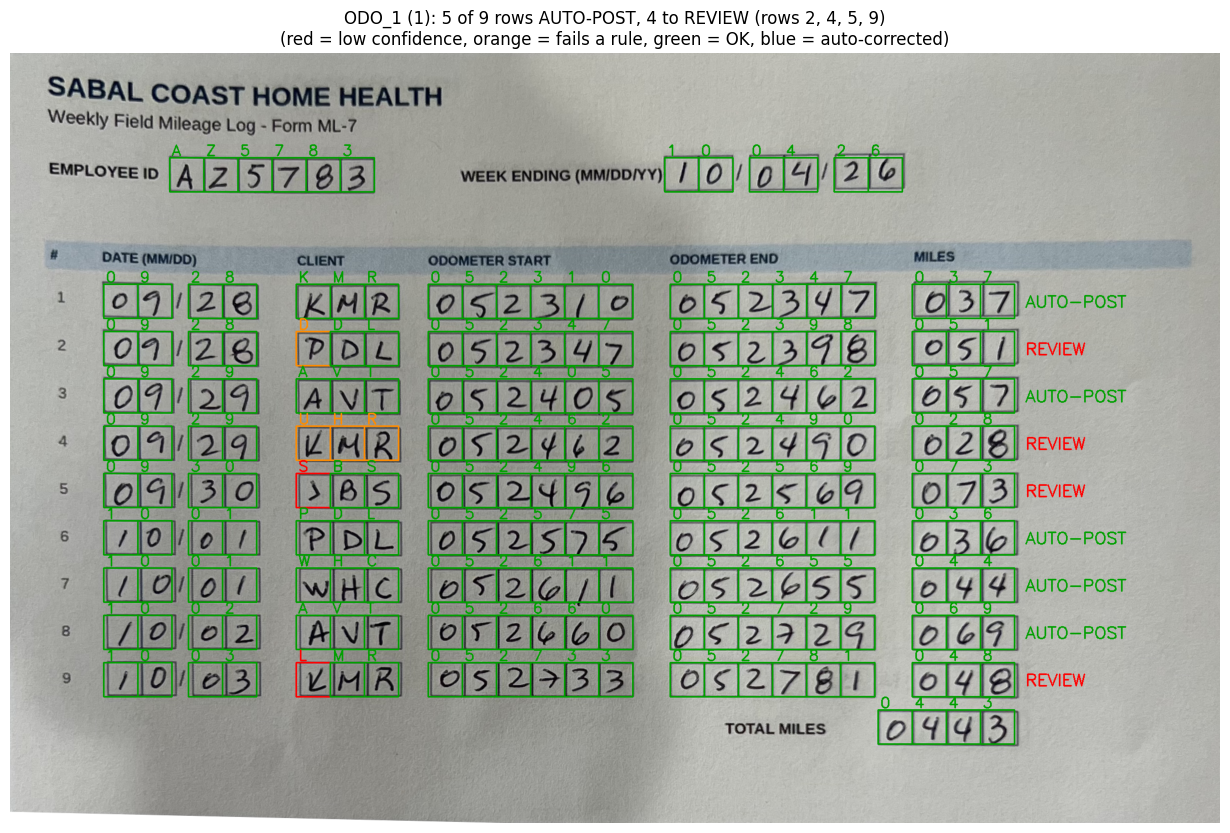

ODO_2 (1).heic   (reference checks OFF) 

Employee ID: QS2047 (lowest confidence 0.99)    Week ending: 091326 (lowest confidence 1.00)
148 feature matches, read in 2.1 s

row  date   client  odo start  odo end    miles  min conf  decision
1    0907   OIS     017420     017469     049    0.94      AUTO-POST
2    0907   BZQ     017469     017538     069    0.96      AUTO-POST
3    0908   OIS     017541     017597     056    0.82      AUTO-POST
4    0909   GSB     017597     017671     074    0.99      AUTO-POST
5    0910   QOD     017675     017713     038    0.98      AUTO-POST
6    0910   BZQ     017713     017757     044    0.90      AUTO-POST
7    0911   QOD     017760     017838     078    0.94      AUTO-POST
8    0912   GSB     017843     617864     041    0.55      REVIEW
9    0913   OIS     017886     017913     027    0.99      REVIEW

Total miles: 0411 (lowest confidence 1.00)

Close calls (confidence below 0.90):
  row 8 odo end, char 5: read '6' (0.55), next guesses '8' (0.32

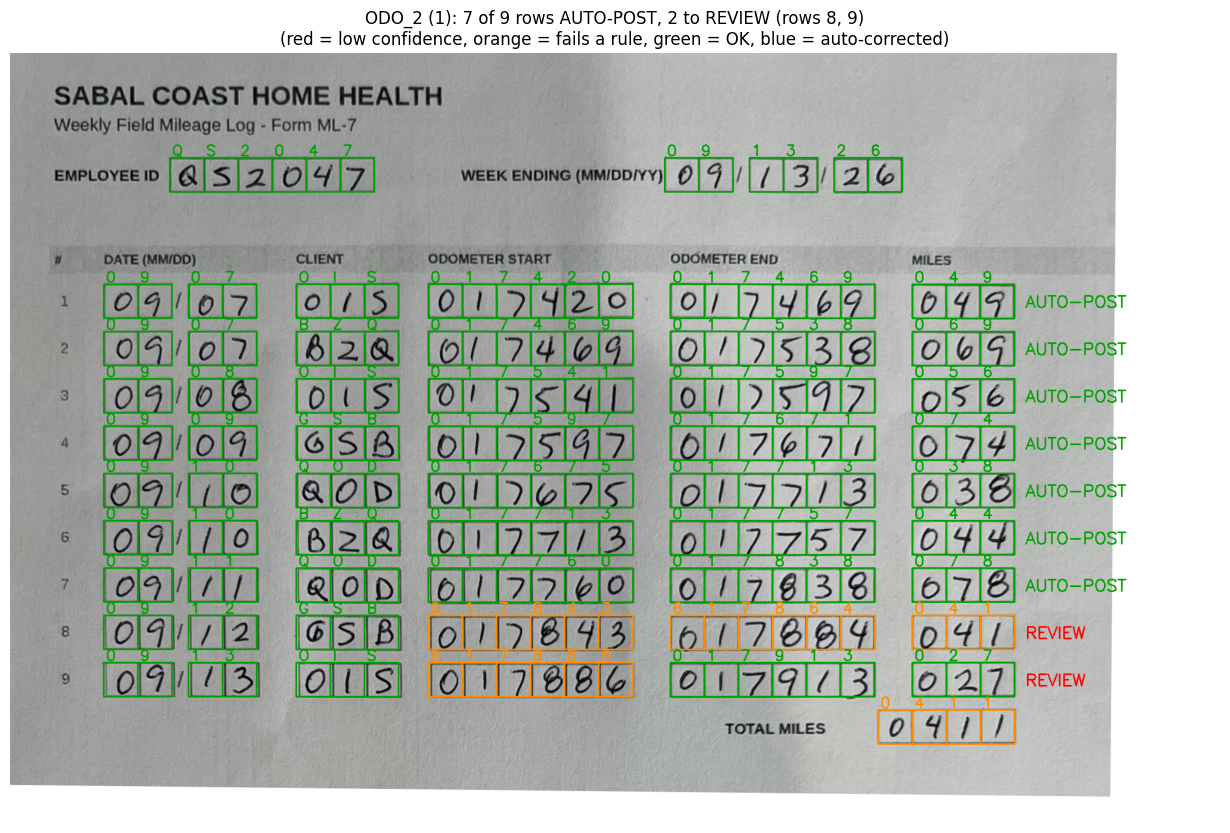

ODO_4 (1).heic  

Employee ID: AZ5783 (lowest confidence 0.98)    Week ending: 092726 (lowest confidence 0.83)
181 feature matches, read in 2.3 s

row  date   client  odo start  odo end    miles  min conf  decision
1    0921   KMR     051790     051846     056    0.56      AUTO-POST
2    0921   PDL     051846     051875     029    0.93      AUTO-POST
3    0922   AVT     051881     051965     084    1.00      AUTO-POST
4    0923   JBS     051965     052008     043    0.92      AUTO-POST
5    0929   WHC     052012     052077     065    0.99      REVIEW
6    0924   KMR     052077     052114     037    0.95      AUTO-POST
7    0925   PDL     052119     052191     072    0.97      AUTO-POST
8    0926   AVT     052191     052209     018    0.06      AUTO-POST
9    0927   JBS     052212     052263     051    0.96      AUTO-POST

Total miles: 0455 (lowest confidence 0.84)

Close calls (confidence below 0.90):
  row 1 miles, char 2: read '5' (0.56), next guesses '3' (0.44), '9' (0.00)
  week en

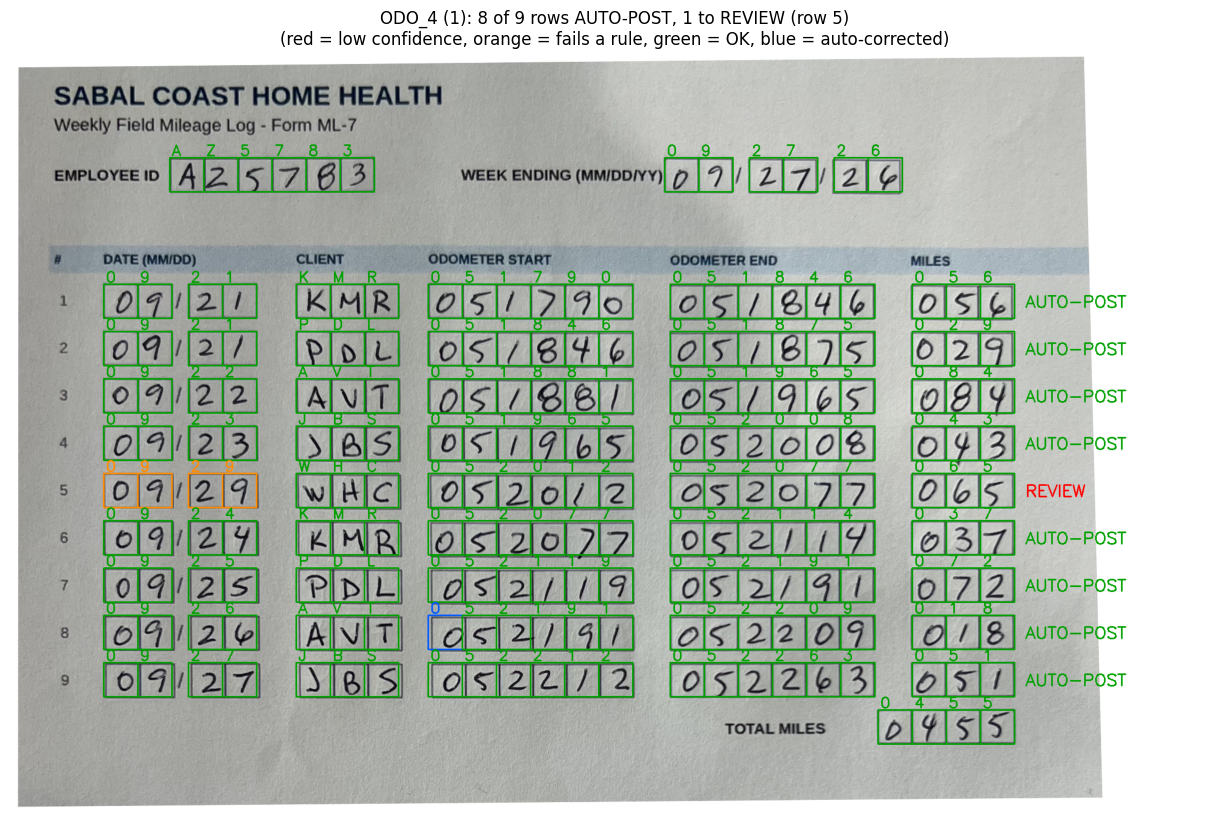

ODO_3 (1).heic  

Employee ID: MT4826 (lowest confidence 0.99)    Week ending: 092026 (lowest confidence 1.00)
116 feature matches, read in 4.6 s

row  date   client  odo start  odo end    miles  min conf  decision
1    0914   GEN     099671     099706     035    0.92      AUTO-POST
2    0914   SOL     099706     099711     005    0.99      AUTO-POST
3    0915   TRB     099718     099783     065    0.92      AUTO-POST
4    0915   MXQ     099783     099831     048    0.99      AUTO-POST
5    0916   SOL     099837     099846     009    0.98      AUTO-POST
6    0917   GEN     099846     099898     052    0.58      AUTO-POST
7    0917   TRB     099902     099959     057    0.98      AUTO-POST
8    0918   SOL     099959     099964     005    0.99      AUTO-POST
9    0919   MXQ     099972     100033     061    0.98      AUTO-POST

Total miles: 0337 (lowest confidence 1.00)

Close calls (confidence below 0.90):
  row 6 client, char 2: read 'E' (0.58), next guesses 'G' (0.40), 'B' (0.02)
  row

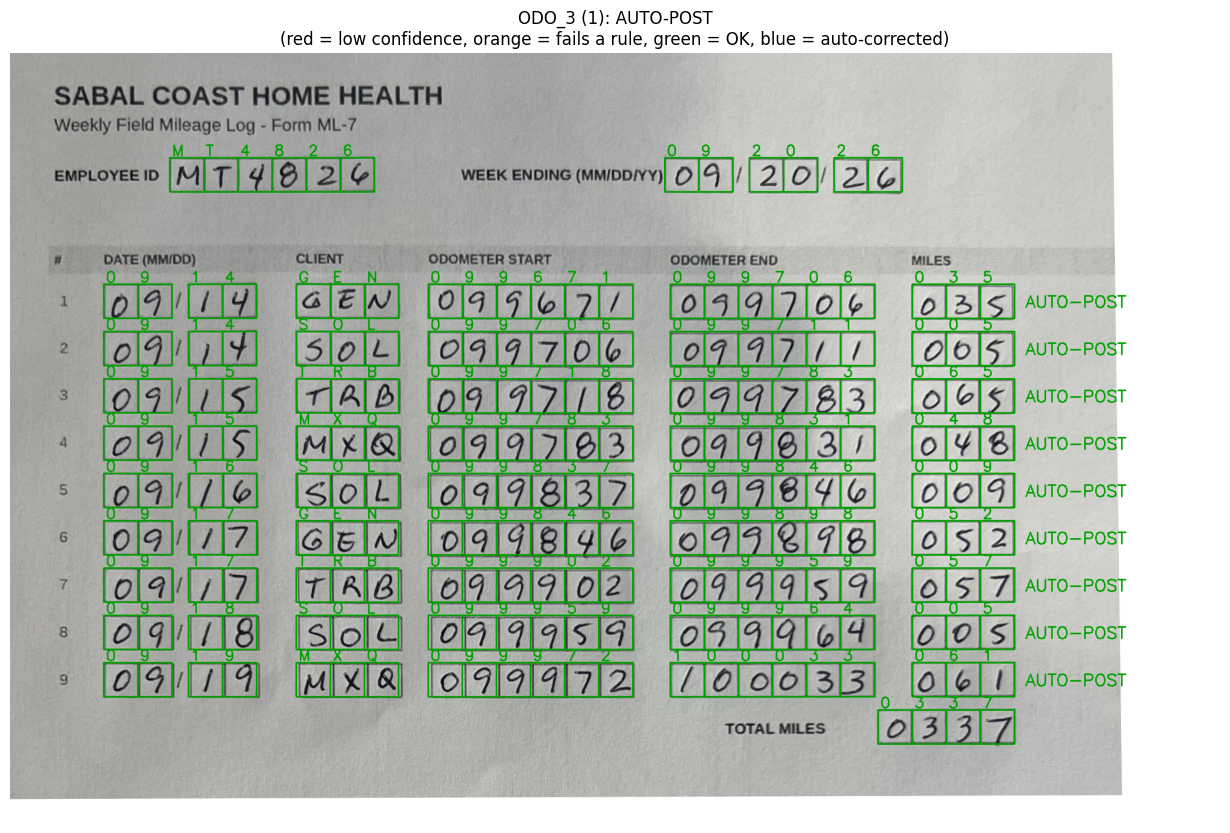

In [ ]:
from google.colab import files

REFERENCE_CHECKS = True            # default for every photo
NO_REFERENCE_CHECKS = {'ODO_2'}    # photos whose file name starts with these skip the HR list, visit schedule and 60-day check
AS_OF = None                       # None = today. To pretend it is another day: AS_OF = dt.date(2026, 10, 12)

uploaded = files.upload()          # pick ONE or SEVERAL photos at once (JPG, PNG or iPhone HEIC)

for name, data in uploaded.items():
    path = UPLOAD_DIR / name
    path.write_bytes(data)
    ref = REFERENCE_CHECKS and not any(path.stem.upper().startswith(n.upper()) for n in NO_REFERENCE_CHECKS)
    print('=' * 110)
    print(name, '' if ref else '  (reference checks OFF)', '\n')
    try:
        res = run_photo(path, reference_checks=ref, as_of=AS_OF)
    except Exception as e:                      # one bad photo must not stop the others
        print('Could not read this photo:', e)
        print('Retake it with the whole form visible, flat, in good light.\n')
        continue
    print_reads(res)
    show_result(path.stem, res)